# Progetto — Classificazione della qualità del vino rosso

L'obiettivo è costruire un modello di classificazione per predire la qualità del vino rosso (`WineQuality`) a partire dalle caratteristiche fisico-chimiche.

Il problema è multiclass: la qualità può assumere valori da 3 a 8.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_predict, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

## Lettura dei dati

Carichiamo il dataset di training e il dataset di test.

In [5]:
train = pd.read_excel("wine_train.xlsx")
test = pd.read_excel("wine_test.xlsx")

train.columns = train.columns.str.strip()
test.columns = test.columns.str.strip()

train.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,Acidity_Sulfur_Interaction,Synthetic_Noise_Flag,Alcohol_Density_Ratio,Volatile_Enhanced,WineQuality
0,7.1,0.45,0.62,6.5,0.012,25,71,1.0013,3.49,0.93,9.1,6.436419,0,9.016522,0,6
1,9.3,0.54,0.43,7.4,0.012,17,76,0.9953,3.31,0.65,11.5,NaN,0,11.667603,0,5
2,8.8,0.45,0.28,1.2,0.090,15,24,0.9956,3.53,0.74,9.8,6.597745,0,NaN,0,5
3,11.1,0.48,0.45,5.6,0.102,12,79,0.9964,3.21,0.52,10.8,5.719312,1,11.304956,0,6
4,9.2,0.61,0.00,4.9,0.155,9,54,0.9945,3.29,0.73,9.4,6.662838,0,10.164500,1,6


## Separazione tra feature e target

Separiamo:

- `X`: variabili predittive;
- `y`: variabile target `WineQuality`.

La target non deve essere modificata nel preprocessing.

In [12]:
# X contiene tutte le variabili predittive, cioè tutte le colonne tranne WineQuality
X = train.drop(columns=["WineQuality", "Synthetic_Noise_Flag", "Volatile_Enhanced"])
# y contiene solo la variabile target, cioè la qualità del vino da predire
y = train["WineQuality"]

y.value_counts().sort_index()

WineQuality
3      3
4     40
5    438
6    409
7    121
8     13
Name: count, dtype: int64

## Preprocessing

Il preprocessing viene applicato solo alle variabili predittive.

Useremo:

- clipping con bounds realistici;
- controllo delle variabili binarie;
- imputazione dei valori mancanti con la media.

Non applichiamo scaling perché Random Forest non lo richiede.

In [ ]:
# Creiamo una copia di X per non modificare direttamente il dataset originale    
X_clean = X.copy()

## Gestione dei valori mancanti

I valori mancanti vengono sostituiti con la media della rispettiva colonna.

L'imputer viene salvato perché dovrà essere riutilizzato anche sul dataset di test.

In [14]:
print("Valori mancanti prima dell'imputazione:")
print(X_clean.isnull().sum())
# Selezioniamo le colonne numeriche
numeric_cols = X_clean.select_dtypes(include=["float64", "int64"]).columns
# Creiamo un imputatore che sostituisce i valori mancanti con la media della colonna
imputer = SimpleImputer(strategy="mean")
# Applichiamo l’imputazione alle colonne numeriche
X_clean[numeric_cols] = imputer.fit_transform(X_clean[numeric_cols])

for col in binary_cols:
    if col in X_clean.columns:
        X_clean[col] = X_clean[col].round().astype(int)

print("Valori mancanti dopo l'imputazione:")
print(X_clean.isnull().sum())

X_clean.head()

Valori mancanti prima dell'imputazione:
fixed_acidity                   0
volatile_acidity                0
citric_acid                     0
residual_sugar                  0
chlorides                       0
free_sulfur_dioxide             0
total_sulfur_dioxide            0
density                         0
pH                              0
sulphates                       0
alcohol                         0
Acidity_Sulfur_Interaction    174
Alcohol_Density_Ratio          93
dtype: int64
Valori mancanti dopo l'imputazione:
fixed_acidity                 0
volatile_acidity              0
citric_acid                   0
residual_sugar                0
chlorides                     0
free_sulfur_dioxide           0
total_sulfur_dioxide          0
density                       0
pH                            0
sulphates                     0
alcohol                       0
Acidity_Sulfur_Interaction    0
Alcohol_Density_Ratio         0
dtype: int64


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,Acidity_Sulfur_Interaction,Alcohol_Density_Ratio
0,7.1,0.45,0.62,6.5,0.012,25.0,71.0,1.0013,3.49,0.93,9.1,6.436419,9.016522
1,9.3,0.54,0.43,7.4,0.012,17.0,76.0,0.9953,3.31,0.65,11.5,5.476156,11.667603
2,8.8,0.45,0.28,1.2,0.090,15.0,24.0,0.9956,3.53,0.74,9.8,6.597745,10.445548
3,11.1,0.48,0.45,5.6,0.102,12.0,79.0,0.9964,3.21,0.52,10.8,5.719312,11.304956
4,9.2,0.61,0.00,4.9,0.155,9.0,54.0,0.9945,3.29,0.73,9.4,6.662838,10.164500


## Train/validation split

Dividiamo il training set in una parte di addestramento e una parte di validazione.

Usiamo `stratify=y` per mantenere una distribuzione simile delle classi.

In [15]:
X_train, X_val, y_train, y_val = train_test_split(
    X_clean,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Random Forest base

Addestriamo un primo modello Random Forest.

In [ ]:
random_forest = RandomForestClassifier(
    n_estimators=200,       # numero di alberi
    max_depth=3,            # profondità massima degli alberi
    random_state=42,        # rende i risultati riproducibili
    class_weight="balanced" # dà più peso alle classi meno frequenti
)

random_forest.fit(X_train, y_train)

y_pred = random_forest.predict(X_val)

## Metriche sul validation set

Poiché il problema è multiclass, usiamo `average="macro"` per precision, recall e F1-score.

In questo modo tutte le classi hanno lo stesso peso nella valutazione.

In [19]:
accuracy = accuracy_score(y_val, y_pred)

precision = precision_score(y_val, y_pred, average="macro", zero_division=0)
recall = recall_score(y_val, y_pred, average="macro", zero_division=0)
f1 = f1_score(y_val, y_pred, average="macro", zero_division=0)

# average="macro" calcola la metrica per ogni classe e poi fai la media, dando lo stesso peso a tutte le classi
# zero_division=0 evita errori se una classe non viene mai predetta
print("Accuracy:", accuracy)
print("Precision macro:", precision)
print("Recall macro:", recall)
print("F1 macro:", f1)

Accuracy: 0.28780487804878047
Precision macro: 0.18429482278098705
Recall macro: 0.1554570091155457
F1 macro: 0.15595193644998656


In [9]:
print(classification_report(y_val, y_pred, zero_division=0))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         0
           4       0.02      0.12      0.04         8
           5       0.44      0.20      0.28        88
           6       0.38      0.39      0.38        82
           7       0.13      0.17      0.15        24
           8       0.00      0.00      0.00         3

    accuracy                           0.27       205
   macro avg       0.16      0.15      0.14       205
weighted avg       0.36      0.27      0.29       205



## Cross-validation

Usiamo la cross-validation per ottenere una valutazione più robusta del modello, ogni osservazione viene predetta da un modello che non l’ha vista in fase di training.

Poiché alcune classi sono poco numerose, usiamo 3 fold.

In [20]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_forest_cv = RandomForestClassifier(
    n_estimators=200,
    max_depth=3,
    random_state=42,
    class_weight="balanced"
)

y_pred_cv = cross_val_predict(
    random_forest_cv,
    X_clean,
    y,
    cv=cv
)

accuracy_cv = accuracy_score(y, y_pred_cv)
precision_cv = precision_score(y, y_pred_cv, average="macro", zero_division=0)
recall_cv = recall_score(y, y_pred_cv, average="macro", zero_division=0)
f1_cv = f1_score(y, y_pred_cv, average="macro", zero_division=0)

print("Accuracy CV:", accuracy_cv)
print("Precision macro CV:", precision_cv)
print("Recall macro CV:", recall_cv)
print("F1 macro CV:", f1_cv)

Accuracy CV: 0.2568359375
Precision macro CV: 0.16514790370169155
Recall macro CV: 0.1672074865812363
F1 macro CV: 0.14915498883795317


## Matrice di confusione

La matrice di confusione mostra quali classi vengono predette correttamente e quali vengono confuse.

Qui usiamo le predizioni ottenute tramite cross-validation.

In [21]:
classi = sorted(y.unique())

conf_matrix = confusion_matrix(
    y,
    y_pred_cv,
    labels=classi
)

conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=classi,
    columns=classi
)

conf_matrix_df.index.name = "Classe reale"
conf_matrix_df.columns.name = "Classe predetta"

conf_matrix_df

Classe predetta,3,4,5,6,7,8
Classe reale,,,,,,
3,0,1,0,0,2,0
4,0,7,8,16,9,0
5,0,82,73,177,100,6
6,0,85,83,158,76,7
7,2,24,24,46,24,1
8,0,2,2,5,3,1


## Grid Search

Ora ottimizziamo gli iperparametri della Random Forest.

La Grid Search prova diverse combinazioni e sceglie quella con F1 macro migliore.

In [22]:
param_grid = {
    "n_estimators": [100, 250, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ),
    param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_search.fit(X_clean, y)

grid_search.best_params_, grid_search.best_score_

({'max_depth': 10,
  'min_samples_leaf': 1,
  'min_samples_split': 5,
  'n_estimators': 250},
 np.float64(0.16521107510568958))

## Modello finale

Usiamo il miglior modello trovato dalla Grid Search e lo addestriamo su tutto il training set.

In [23]:
best_model = grid_search.best_estimator_

best_model.fit(X_clean, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",250
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## Feature importance

Analizziamo quali variabili sono più importanti per il modello Random Forest.

In [24]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X_clean.columns
).sort_values(ascending=False)

feature_importance

Alcohol_Density_Ratio         0.114936
pH                            0.100647
chlorides                     0.096187
free_sulfur_dioxide           0.078048
density                       0.075236
volatile_acidity              0.072995
Acidity_Sulfur_Interaction    0.072270
alcohol                       0.071265
total_sulfur_dioxide          0.069255
citric_acid                   0.065912
sulphates                     0.065713
fixed_acidity                 0.060672
residual_sugar                0.056864
dtype: float64

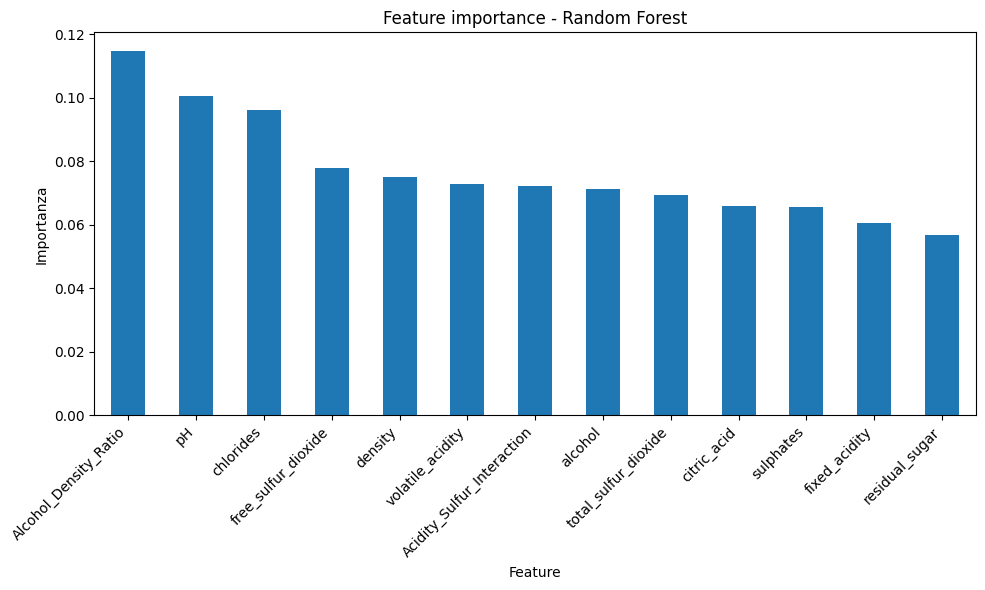

In [25]:
plt.figure(figsize=(10, 6))
feature_importance.plot(kind="bar")
plt.title("Feature importance - Random Forest")
plt.xlabel("Feature")
plt.ylabel("Importanza")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Preprocessing del dataset di test

Applichiamo al test set lo stesso preprocessing usato sul training set:

- stesso clipping;
- stessa imputazione;
- stesso trattamento delle variabili binarie.

Il test set non viene usato per addestrare il modello.

In [27]:
test_features = test.copy()

if "WineQuality" in test_features.columns:
    test_features = test_features.drop(columns=["WineQuality", "Synthetic_Noise_Flag", "Volatile_Enhanced"])

test_features = test_features[X_clean.columns]

test_clean = test_features.copy()

for col in bounds:
    if col in test_clean.columns:
        lower = bounds[col][0]
        upper = bounds[col][1]
        test_clean[col] = test_clean[col].clip(lower=lower, upper=upper)

for col in binary_cols:
    if col in test_clean.columns:
        test_clean[col] = test_clean[col].clip(lower=0, upper=1)

test_clean[numeric_cols] = imputer.transform(test_clean[numeric_cols])

for col in binary_cols:
    if col in test_clean.columns:
        test_clean[col] = test_clean[col].round().astype(int)

test_clean.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,Acidity_Sulfur_Interaction,Alcohol_Density_Ratio
0,8.8,0.48,0.66,1.2,0.053,34.0,61.0,0.9967,3.26,0.82,9.5,7.267484,9.089129
1,7.7,0.69,0.09,1.2,0.084,1.0,31.0,0.9944,3.40,0.66,9.6,5.476156,10.513058
2,6.9,0.38,0.13,2.6,0.012,7.0,66.0,0.9949,3.15,0.42,10.9,2.940180,11.104644
3,8.5,0.58,0.01,1.6,0.057,11.0,11.0,0.9957,3.21,0.51,11.2,4.311858,10.890228
4,9.0,0.31,0.52,1.2,0.098,6.0,88.0,0.9954,3.37,0.83,10.0,7.495080,9.389312


## Predizione sul dataset di test

Usiamo il modello finale per predire la qualità dei vini nel test set.

In [28]:
test_predictions = best_model.predict(test_clean)

test["Predicted_WineQuality"] = test_predictions

test.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,Acidity_Sulfur_Interaction,Synthetic_Noise_Flag,Alcohol_Density_Ratio,Volatile_Enhanced,WineQuality,Predicted_WineQuality
0,8.8,0.48,0.66,1.2,0.053,34,61,0.9967,3.26,0.82,9.5,7.267484,0,9.089129,0,5,6
1,7.7,0.69,0.09,1.2,0.084,1,31,0.9944,3.40,0.66,9.6,NaN,0,10.513058,1,7,6
2,6.9,0.38,0.13,2.6,0.012,7,66,0.9949,3.15,0.42,10.9,2.940180,0,11.104644,0,5,6
3,8.5,0.58,0.01,1.6,0.057,11,11,0.9957,3.21,0.51,11.2,4.311858,0,10.890228,0,6,6
4,9.0,0.31,0.52,1.2,0.098,6,88,0.9954,3.37,0.83,10.0,7.495080,0,9.389312,0,6,5


In [29]:
test.to_excel("wine_test_predictions.xlsx", index=False)